# Importation des librairies 

In [2]:
import numpy as np
import pandas as pd
#import matplotlib as mpl
#%matplotlib inline
import matplotlib.pyplot as plt
import missingno as msno
import plotly
import plotly.figure_factory as ff
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
import plotly.express as px
import time 
#import scipy
#from scipy.stats import normaltest
import seaborn as sns
import sys


#%matplotlib inline

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

# Versions
print('Version des librairies utilisées :')

print('NumPy                 : ' + np.version.full_version)
print('Pandas                : ' + pd.__version__)
print('Python                : ' + sys.version)
print('Plotly                : ' + plotly.__version__)
#print('Matplotlib            : ' + mpl.__version__)
#print('Scipy                 : '+ scipy.__version__)
print('Seaborn               : ' + sns.__version__)
#print('Sklearn               : ' + sklearn.__version__)
#print('jyquickhelper         : ' + jyquickhelper.__version__)

Version des librairies utilisées :
NumPy                 : 1.26.4
Pandas                : 2.2.2
Python                : 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
Plotly                : 5.24.1
Seaborn               : 0.13.2


## <span style='background:Thistle'>Description des datasets : </span>

**Objectif**:

Comprendre au maximum les données dont on dispose pour définir une stratégie de segmentation.

**Analyse de la forme** :

**orders**: informations sur les commandes et leurs métadonnées
  
  -**variable target**: order_id mais reste à identifier
  
  -**Nombre des lignes et de colonnes**: 99441, 8
  
  -**Types de variables** :8 qualitatives
  
  -**Analyse des valeurs manquantes** : moins de 5 % uniquemment sur les dates de livraison et de depart de livraison et data de confirmation de commande
>les types colonnes temporelles sont à corriger si on les garde.
*****
**orders_item**: informations sur le contenu des commandes

  -**variable target** : order_id , customer_id, seller_id,
  
  -**Nombre des lignes et de colonnes** : 112650, 7
  
  -**Types de variables** :4 qualitatives, 3 quantitatives
  
  -**Analyse des valeurs manquantes** : aucune
*****
**order_review**: informations sur les commantaires des commandes

  
  -**variable target** : order_id, review_score
  
  -**Nombre des lignes et de colonnes** : 99224, 7
  
  -**Types de variables** :6 qualitatives, 1 quantitatives
  
  -**Analyse des valeurs manquantes** : 90% et 60% sur les commentaires et leurs titres.
>mettre " " pour corriger
*****
**products**: informations sur les produits, nom, taille, photos

  -**variable target** : product_id, product_category_name
  
  -**Nombre des lignes et de colonnes** : 32951, 9
  
  -**Types de variables** :7 qualitatives, 2 quantitatives
  
  -**Analyse des valeurs manquantes** : environ 8 % sur les dimensions et la catégorie
>73 catégories différentes > Tenter de réduire ce nombre.
>A traduire avec le dataset category name
*****
**payments**: informations sur les paiements, montant, echelonnés ou pas, payé avec bon d'achat ou non

  -**variable target** : product_id, product_category_name
  
  -**Nombre des lignes et de colonnes** : 103886, 5
  
  -**Types de variables** :2 qualitatives, 3 quantitatives
 
  -**Analyse des valeurs manquantes** : aucune
*****
**customer**: informations sur les clients, et leur origine

  -**variable target** : customer_unique_id,
  
  -**Nombre des lignes et de colonnes** : 99441, 5
  
  -**Types de variables** :4 qualitatives, 1 quantitatives
  
  -**Analyse des valeurs manquantes** : 0 valeurs manquantes
*****
**sellers**: informations sur les vendeurs, localisation

  -**variable target** : seller_id
  
  -**Nombre des lignes et de colonnes** : 3095, 4
  
  -**Types de variables** : 3 qualitatives, 1 quantitatives
  
  -**Analyse des valeurs manquantes** : 0 valeurs manquantes
******
**geolocation**: informations sur la localisation des code postaux et villes utilisés dans les autres dataset

  -**variable target** : zip code
  
  -**Nombre des lignes et de colonnes** : 1000163, 5
  
  -**Types de variables** :2 qualitatives, 3 quantitatives
  
  -**Analyse des valeurs manquantes** : 0 valeurs manquantes
>8011 villes différentes or selon internet https://cidades.ibge.gov.br/brasil/panoramail y en a 5570 , des corrections a faire au niveau de accents et enventuellement traduction.
*****
**category_name**: traduction en anglais des noms de produits

  -**variable target** : product name
  
  -**Nombre des lignes et de colonnes** : 71, 2
  
  -**Types de variables** :2 qualitatives
  
  -**Analyse des valeurs manquantes** : 0 valeurs manquantes

# Chargement des données : 

In [6]:
#chargement des données 
orders = pd.read_csv("olist_orders_dataset.csv")

order_item = pd.read_csv("olist_order_items_dataset.csv")

order_review = pd.read_csv("olist_order_reviews_dataset.csv")

products = pd.read_csv("olist_products_dataset.csv")

payments = pd.read_csv("olist_order_payments_dataset.csv")

customer = pd.read_csv("olist_customers_dataset.csv")

sellers = pd.read_csv("olist_sellers_dataset.csv")

geolocation = pd.read_csv("olist_geolocation_dataset.csv")

category_name = pd.read_csv("product_category_name_translation.csv")

In [7]:
def description_dataset(data, matrix):
    '''
    Return the description of a dataset
    
        Parameters: 
            data: dataframe
            matrix(bool): indicates if we plot the msno matrix of data
            
        Returns:
            the 3 first line of the dataframe
            the shape, the types, th number of null values,
            the number of unique values, the number of duplicated values
            
    '''
    if matrix == True:
        msno.matrix(data)
        
    display(data.head(3))
    print(f'Taille :-------------------------------------------------------------- {data.shape}')
    print("--"*50)
    print(f'Types :{data.dtypes.value_counts()}')
    print("--"*50)
    print(f'Types :{data.dtypes}')
    print("--"*50)
    print("Valeurs manquantes par colonnes (%): ")
    print((((data.isna().sum()/data.shape[0])*100).round(2)).sort_values(ascending= False))
    print("--"*50)
    print("Valeurs différentes par variables : ")
    for col in data:
        if data[col].nunique() < 30:
            print (f'{col :-<70} {data[col].unique()}')
        else : 
            print(f'{col :-<70} contient {data[col].nunique()} valeurs différentes')
    print("--"*50)
    print(f"Nombre de doublons : {data.duplicated().sum()}")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


Taille :-------------------------------------------------------------- (99441, 8)
----------------------------------------------------------------------------------------------------
Types :object    8
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Types :order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
order_delivered_customer_date    2.98
order_delivered_carrier_date     1.79
order_approved_at                0.16
order_id                         0.00
customer_id                      0.00
o

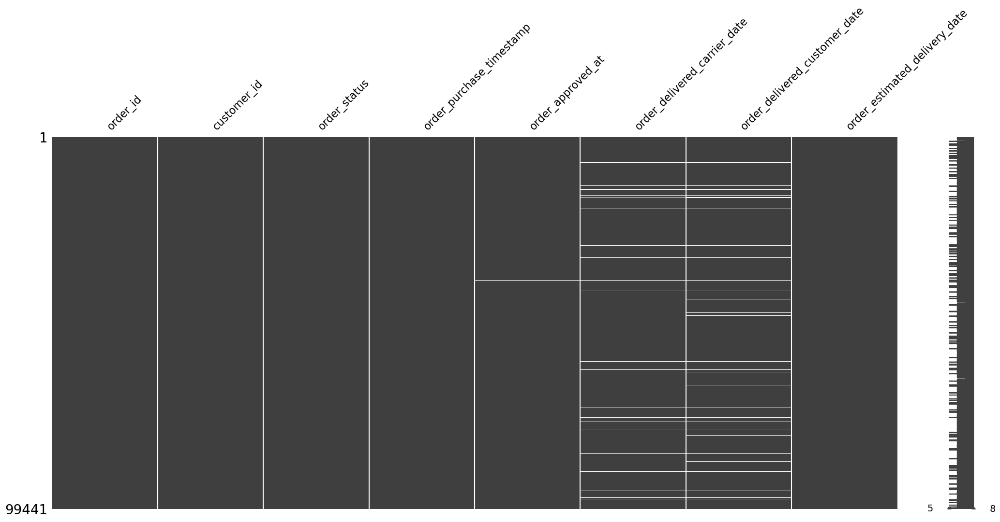

In [8]:
description_dataset(orders, matrix=True)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


Taille :-------------------------------------------------------------- (112650, 7)
----------------------------------------------------------------------------------------------------
Types :object     4
float64    2
int64      1
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Types :order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
order_id               0.0
order_item_id          0.0
product_id             0.0
seller_id              0.0
shipping_limit_date    0.0
price                  0.0
freight_value          0.0
dtype: float64
--------------------------------------------------------------

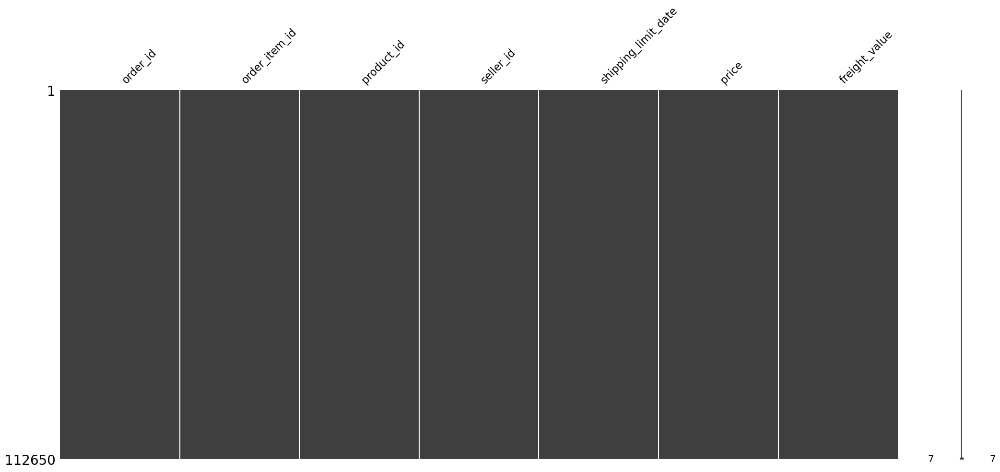

In [9]:
description_dataset(order_item, matrix = True)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


Taille :-------------------------------------------------------------- (99224, 7)
----------------------------------------------------------------------------------------------------
Types :object    6
int64     1
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Types :review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
review_comment_title       88.34
review_comment_message     58.70
review_id                   0.00
order_id                    0.00
review_score                0.00
review_creation_date        0.00
review_answer_timestamp     0.00
dtype: float64
---------------

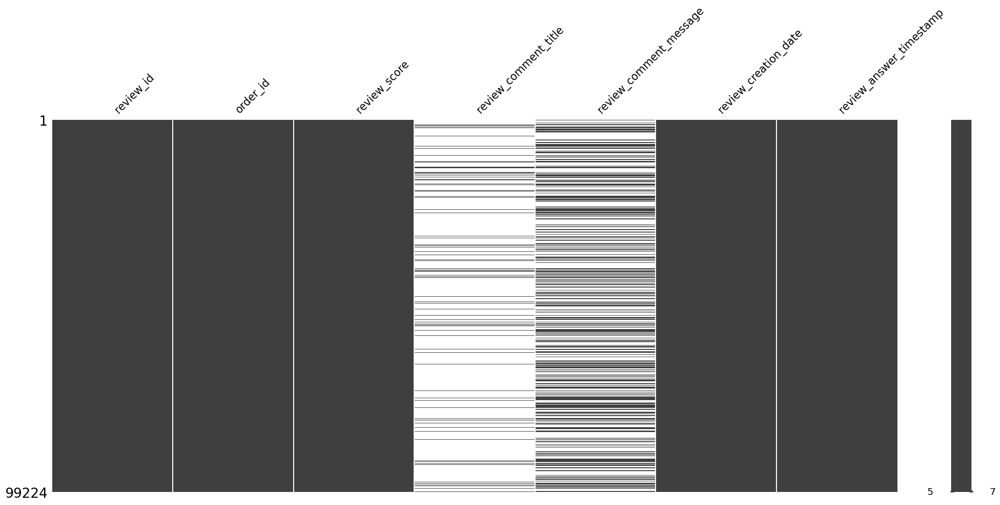

In [10]:
description_dataset(order_review, matrix = True)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


Taille :-------------------------------------------------------------- (32951, 9)
----------------------------------------------------------------------------------------------------
Types :float64    7
object     2
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Types :product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_

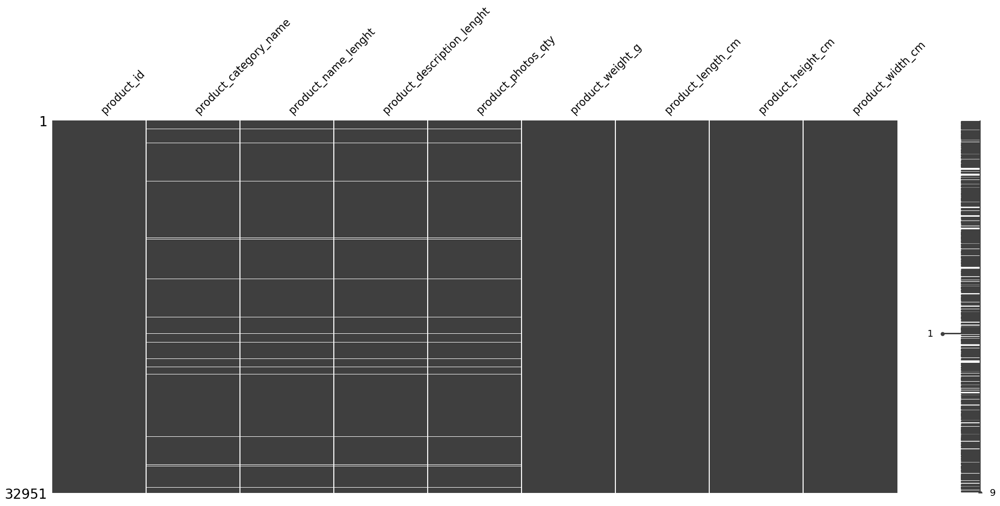

In [11]:
description_dataset(products, matrix = True)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


Taille :-------------------------------------------------------------- (103886, 5)
----------------------------------------------------------------------------------------------------
Types :object     2
int64      2
float64    1
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Types :order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
order_id                0.0
payment_sequential      0.0
payment_type            0.0
payment_installments    0.0
payment_value           0.0
dtype: float64
----------------------------------------------------------------------------------------------------
Valeurs différentes par variables : 
order_id----------------------

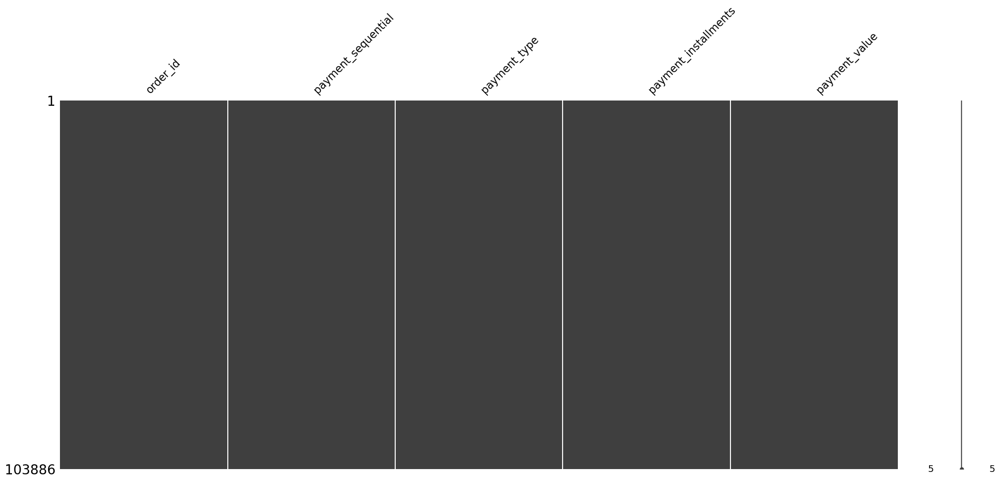

In [12]:
description_dataset(payments, matrix = True)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


Taille :-------------------------------------------------------------- (99441, 5)
----------------------------------------------------------------------------------------------------
Types :object    4
int64     1
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Types :customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
customer_id                 0.0
customer_unique_id          0.0
customer_zip_code_prefix    0.0
customer_city               0.0
customer_state              0.0
dtype: float64
----------------------------------------------------------------------------------------------------
Valeurs différentes par variables : 
customer_id

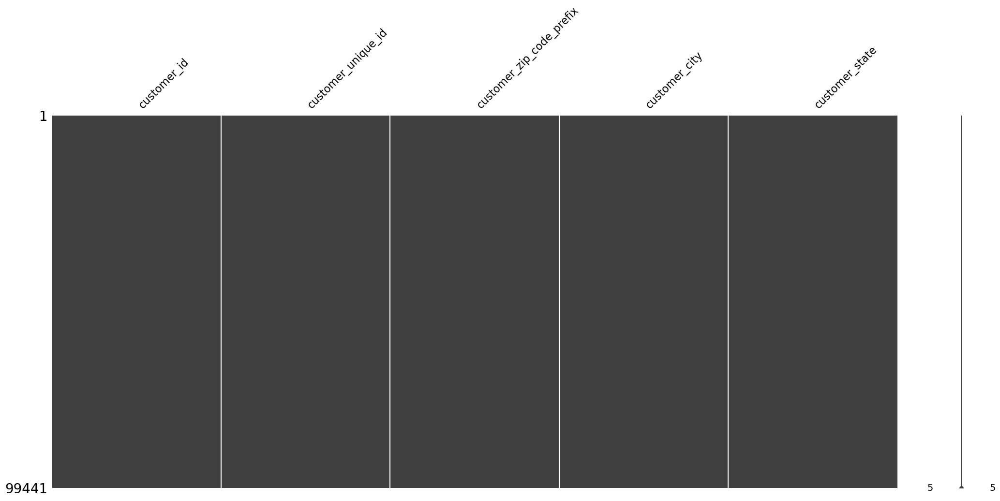

In [13]:
description_dataset(customer, matrix = True)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


Taille :-------------------------------------------------------------- (3095, 4)
----------------------------------------------------------------------------------------------------
Types :object    3
int64     1
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Types :seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
seller_id                 0.0
seller_zip_code_prefix    0.0
seller_city               0.0
seller_state              0.0
dtype: float64
----------------------------------------------------------------------------------------------------
Valeurs différentes par variables : 
seller_id------------------------------------------------------------- contient 3095 valeurs di

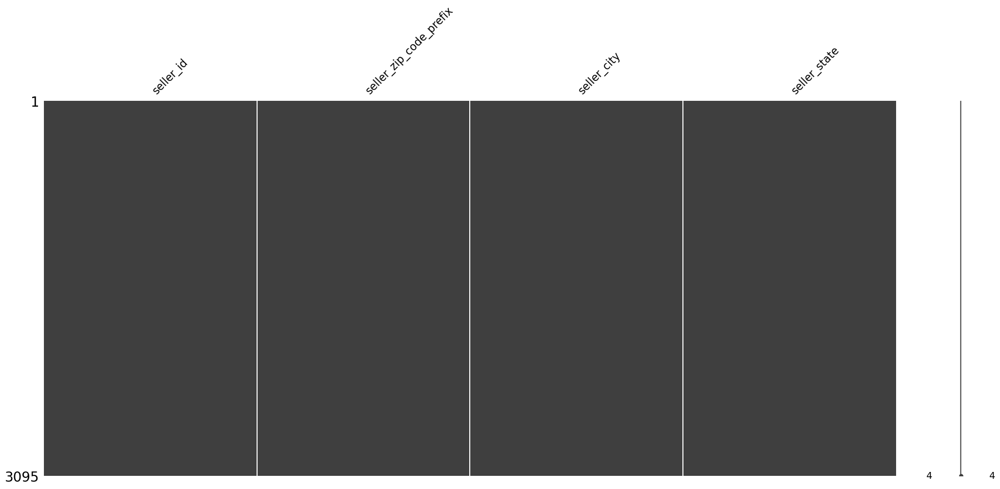

In [14]:
description_dataset(sellers, matrix = True)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP


Taille :-------------------------------------------------------------- (1000163, 5)
----------------------------------------------------------------------------------------------------
Types :float64    2
object     2
int64      1
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Types :geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
geolocation_zip_code_prefix    0.0
geolocation_lat                0.0
geolocation_lng                0.0
geolocation_city               0.0
geolocation_state              0.0
dtype: float64
-------------------------------------------------------------------------------------------------

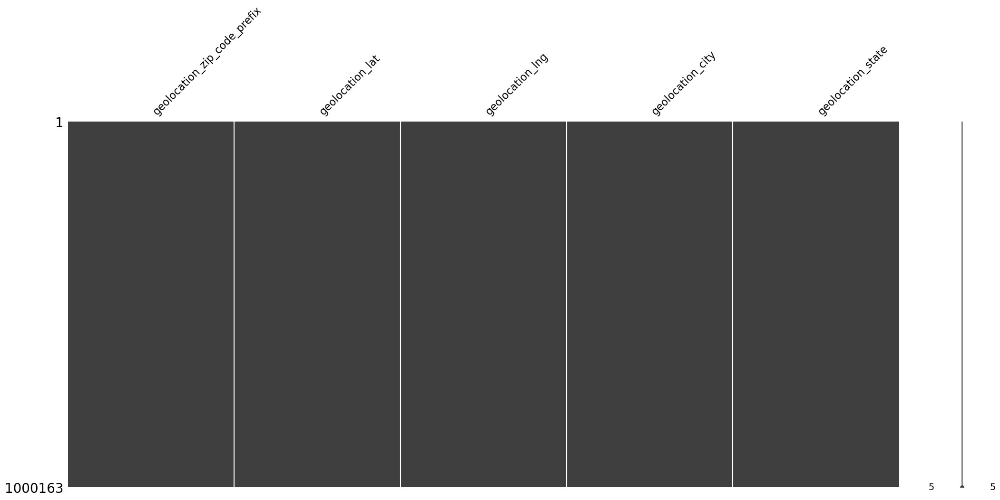

In [15]:
description_dataset(geolocation, matrix = True)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


Taille :-------------------------------------------------------------- (71, 2)
----------------------------------------------------------------------------------------------------
Types :object    2
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Types :product_category_name            object
product_category_name_english    object
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
product_category_name            0.0
product_category_name_english    0.0
dtype: float64
----------------------------------------------------------------------------------------------------
Valeurs différentes par variables : 
product_category_name------------------------------------------------- contient 71 valeurs différentes
product_category_name_english----------------------------------------- contient 71 valeurs différentes
-

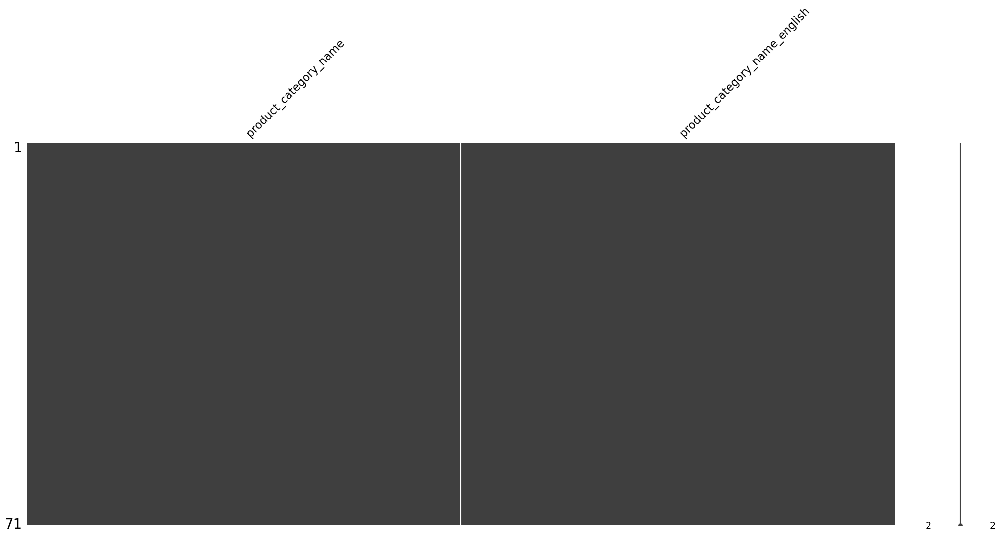

In [16]:
description_dataset(category_name, matrix = True)

In [17]:
df_cus = customer.groupby(['customer_unique_id']).count()
df_cus.customer_id.value_counts()

customer_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

Un client est identifié grâce un identifiant unique, mais à chaque commande il y a un identifiant de client qui se crée. Nous allons devoir traiter cette information.



In [19]:
df_cus.loc[ "b6c083700ca8c135ba9f0f132930d4e8"]

customer_id                 2
customer_zip_code_prefix    2
customer_city               2
customer_state              2
Name: b6c083700ca8c135ba9f0f132930d4e8, dtype: int64

In [20]:
description_dataset(sellers, matrix = False)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


Taille :-------------------------------------------------------------- (3095, 4)
----------------------------------------------------------------------------------------------------
Types :object    3
int64     1
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Types :seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
seller_id                 0.0
seller_zip_code_prefix    0.0
seller_city               0.0
seller_state              0.0
dtype: float64
----------------------------------------------------------------------------------------------------
Valeurs différentes par variables : 
seller_id------------------------------------------------------------- contient 3095 valeurs di

In [21]:
description_dataset(geolocation,matrix = False)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP


Taille :-------------------------------------------------------------- (1000163, 5)
----------------------------------------------------------------------------------------------------
Types :float64    2
object     2
int64      1
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Types :geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
geolocation_zip_code_prefix    0.0
geolocation_lat                0.0
geolocation_lng                0.0
geolocation_city               0.0
geolocation_state              0.0
dtype: float64
-------------------------------------------------------------------------------------------------

In [22]:
description_dataset(category_name,matrix = False)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


Taille :-------------------------------------------------------------- (71, 2)
----------------------------------------------------------------------------------------------------
Types :object    2
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Types :product_category_name            object
product_category_name_english    object
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
product_category_name            0.0
product_category_name_english    0.0
dtype: float64
----------------------------------------------------------------------------------------------------
Valeurs différentes par variables : 
product_category_name------------------------------------------------- contient 71 valeurs différentes
product_category_name_english----------------------------------------- contient 71 valeurs différentes
-

Aucun de nos dataset n'a de valeurs en double sauf celui de geolocation.



## Nettoyage des data frames




### Duplicatas et valeurs manquantes


In [26]:
#Duplicatas
geolocation.drop_duplicates(inplace = True)

In [27]:
# Valeurs manquantes, on traite les variables succeptibles d'être utilisées
products.product_category_name.fillna("unknown", inplace = True)

order_review.fillna(" ", inplace= True)

orders['order_approved_at'].fillna(0, inplace=True) 
orders['order_delivered_carrier_date'].fillna(0, inplace=True)
orders['order_delivered_customer_date'].fillna(0, inplace=True)

### Suppression des accents des noms de villes


In [29]:
import unicodedata
def timeit(f):

    def timed(*args, **kw):

        ts = time.time()
        result = f(*args, **kw)
        te = time.time()

        print (f"Durée d'exécution de {f.__name__}: {te-ts}s")
        return result

    return timed


def strip_accents(text):
    """
    Strip accents from input String.

        param text: The input string.
        type text: String.

    returns: The processed String.
    rtype: String.
    """
    try:
        text = unicode(text, 'utf-8')
    except (TypeError, NameError): # unicode is a default on python 3 
        pass
    text = unicodedata.normalize('NFKD', text)
    text = text.encode('ascii', 'ignore')
    text = text.decode("utf-8")
    return str(text)

In [30]:
geolocation.geolocation_city = geolocation.geolocation_city.apply(lambda x: strip_accents(x))


In [31]:
geolocation.geolocation_city.nunique()

5968

### Mapping des catégories


In [33]:
#Nettoyage avant traduction des catégories de produits 
print("Il manque ces catégories dans la traduction en anglais : ",
      set(products.product_category_name)- set(category_name.product_category_name))
t = len(category_name)

category_name.loc[t,'product_category_name'] = 'unknown'
category_name.loc[t,'product_category_name_english'] = 'unknown'

category_name.loc[t+1,'product_category_name'] = 'pc_gamer'
category_name.loc[t+1,'product_category_name_english'] = 'pc_gamer'

category_name.loc[t+2,'product_category_name'] = 'portateis_cozinha_e_preparadores_de_alimentos'
category_name.loc[t+2,'product_category_name_english'] = 'small_appliances_kitchen_and_food_processors'

products_en = pd.merge(category_name,products, on =["product_category_name"])


Il manque ces catégories dans la traduction en anglais :  {'pc_gamer', 'unknown', 'portateis_cozinha_e_preparadores_de_alimentos'}


In [34]:
categories = {
    #appliances : electroménager
    'home_appliances' :'appliances',
    'home_appliances_2' : 'appliances',
    'small_appliances_kitchen_and_food_processors' : 'appliances',
    'small_appliances_home_oven_and_coffee' : 'appliances',
    'small_appliances': 'appliances',
    'air_conditioning' : 'appliances',
    
    #tools : outils
    'garden_tools': 'tools',
    'costruction_tools_garden' : 'tools',
    'home_construction' : 'tools',
    'costruction_tools_tools' : 'tools',
    'construction_tools_lights' : 'tools',
    'construction_tools_construction' : 'tools', 
    'construction_tools_safety' : 'tools', 
    
    #electronique
    'electronics' : 'electronics',
    'computers_accessories': 'electronics',
    'telephony' : 'electronics',
    'consoles_games' : 'electronics',
    'computers' : 'electronics',
    'pc_gamer' : 'electronics',
    'fixed_telephony' : 'electronics',
    'tablets_printing_image' : 'electronics',
    
    #hygiene et beauté
    'health_beauty' : 'hygiene_and_beauty',
    'perfumery' : 'hygiene_and_beauty',
    'diapers_and_hygiene': 'hygiene_and_beauty', 
     #loisirs et auto
    'sports_leisure' : 'auto_leisure', 
    'toys': 'auto_leisure',
     'auto': 'auto_leisure',
    
    #fashion
    'watches_gifts' : 'fashion',  
    'fashion_bags_accessories' : 'fashion',
    'fashion_shoes': 'fashion',
    'fashion_male_clothing' : 'fashion',
    'fashio_female_clothing' : 'fashion',
    'fashion_childrens_clothes' : 'fashion',
    'fashion_underwear_beach' : 'fashion',
    'fashion_sport' : 'fashion',
    'baby' : 'fashion',
    'luggage_accessories' : 'fashion', 
     
    #mobilier
    'kitchen_dining_laundry_garden_furniture' : 'furniture',
    'furniture_living_room' : 'furniture', 
    'furniture_mattress_and_upholstery' : 'furniture',
    'office_furniture' : 'furniture',
    'furniture_bedroom' : 'furniture',
    
    #articles de décoration
    'furniture_decor': 'decoration' ,
    'christmas_supplies': 'decoration',
    'party_supplies': 'decoration',
    'bed_bath_table' : 'decoration',
   
    #articles ménagers
    'housewares': 'housewares',
    'home_confort' : 'housewares',
    'home_comfort_2' : 'housewares',
    'la_cuisine': 'housewares',
    'stationery': 'housewares',
       
    #jardin et extérieurs
    'pet_shop': 'garden_outdoors',
    'flowers': 'garden_outdoors', 
    'signaling_and_security' : 'garden_outdoors' ,
    #services
    'market_place' : 'service',   
    'industry_commerce_and_business' : 'services',
    'security_and_services' : 'services', 
    
    #culture 
    'arts_and_craftmanship' : 'culture',   
    'books_technical': 'culture',
    'books_general_interest': 'culture',
    'books_imported': 'culture',
    'musical_instruments' : 'culture',
    'cds_dvds_musicals' : 'culture',
    'dvds_blu_ray' : 'culture',
    'cine_photo' : 'culture',
    'audio' : 'culture',
    'music' : 'culture',
    'art' : 'culture', 
    
    #aliments et boissons
    'food': 'food_drinks',
    'food_drink' : 'food_drinks',
    'drinks': 'food_drinks',
    'agro_industry_and_commerce' : 'food_drinks',
    
    #autres
    'cool_stuff': "other",
    'unknown' : "other", 
}
  

In [35]:
products_en['product_category_name'] = products_en['product_category_name_english'].astype('object')
products_en['product_category_name'] = products_en ['product_category_name_english'].replace(categories, regex=False)


## Merge des Dataframes : 



In [37]:
df= pd.merge(orders, customer,
             how= 'left',
             on= ['customer_id']).merge(payments,
                how='left',
                on='order_id').merge(order_item,
                how='left',
                on='order_id').merge(products_en,
                how='left',
                on='product_id').merge(sellers,
                how='left',
                on='seller_id').merge(order_review,
                how='left',
                on = 'order_id')

In [38]:
df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,credit_card,1.0,18.12,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,housewares,housewares,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3.0,voucher,1.0,2.00,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,housewares,housewares,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2.0,voucher,1.0,18.59,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,housewares,housewares,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,boleto,1.0,141.46,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,hygiene_and_beauty,perfumery,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,credit_card,3.0,179.12,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,auto_leisure,auto,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,e73b67b67587f7644d5bd1a52deb1b01,5.0,,,2018-08-18 00:00:00,2018-08-22 19:07:58


>On convertit les colonnes en format date 

In [40]:
date_cols = ['order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date']


df[date_cols] = df[date_cols].apply(pd.to_datetime, errors='coerce')


On ne garde que les commandes livrées



In [42]:
df.order_status.value_counts()

order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64

In [43]:
df = df[df.order_status == 'delivered']


In [44]:
print("Date du dernier achat", df.order_purchase_timestamp.max())
print("Date du premier achat", df.order_purchase_timestamp.min())

Date du dernier achat 2018-08-29 15:00:37
Date du premier achat 2016-09-15 12:16:38


In [45]:
last_order = df.order_purchase_timestamp.max()
df['days_since_last_order'] = (last_order - df.order_purchase_timestamp).dt.days


# Feature engineering

## Nombre de produits par commandes

In [48]:
quantity_order = df.groupby(['order_id','product_id']).size().reset_index(name='order_item_quantity')


In [49]:
df = pd.merge(quantity_order,df,how = 'left',  on=['order_id', 'product_id']).drop_duplicates().reset_index(drop=True)


In [50]:
df = df.drop(axis = 1, columns = "order_item_id")


In [51]:
df

,order_id,product_id,order_item_quantity,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,days_since_last_order
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,1,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,1.0,credit_card,2.0,72.19,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,other,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,27277.0,volta redonda,SP,97ca439bc427b48bc1cd7177abe71365,5.0,,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03,350
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,1,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,1.0,credit_card,3.0,259.83,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,garden_outdoors,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,3471.0,sao paulo,SP,7b07bacd811c4117b742569b04ce3580,4.0,,,2017-05-13 00:00:00,2017-05-15 11:34:13,490
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,1,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,1.0,credit_card,5.0,216.87,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,decoration,furniture_decor,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,37564.0,borda da mata,MG,0c5b33dea94867d1ac402749e5438e8b,5.0,,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31,227
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,1,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,1.0,credit_card,2.0,25.78,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,hygiene_and_beauty,perfumery,42.0,480.0,1.0,200.0,16.0,10.0,15.0,14403.0,franca,SP,f4028d019cb58564807486a6aaf33817,4.0,,,2018-08-15 00:00:00,2018-08-15 16:39:01,21
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,1,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,1.0,credit_card,3.0,218.04,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,tools,garden_tools,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,87900.0,loanda,PR,940144190dcba6351888cafa43f3a3a5,5.0,,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59,571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115718,fffc94f6ce00a00581880bf54a75a037,4aa6014eceb682077f9dc4bffebc05b0,1,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18,0c9aeda10a71f369396d0c04dce13a64,65077,sao luis,MA,1.0,boleto,1.0,343.40,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,hou

## Nombre de produits par clients


In [53]:
quantity_per_customer = df.groupby(['customer_id'])['product_id'].count().reset_index(name= 'tot_product')


In [54]:
df = pd.merge(quantity_per_customer, df,how = 'left', on=['customer_id']).drop_duplicates().reset_index(drop=True)


In [55]:
df.tot_product.equals(df.order_item_quantity)

False

In [56]:
paie = df.sort_values(['customer_id','payment_type','payment_installments'],ascending=False).groupby(
        ['customer_id', 'payment_type','payment_installments']).head(1)[[
        'customer_id', 'payment_type','payment_installments']]
paie.rename(columns = {'payment_type' : 'prefered_payment',
           'payment_installments' : 'most_frequent_number_of_payments'}, inplace= True)


In [57]:
paie

,customer_id,prefered_payment,most_frequent_number_of_payments
105306,ffffa3172527f765de70084a7e53aae8,credit_card,4.0
105305,ffff42319e9b2d713724ae527742af25,credit_card,2.0
105304,fffeda5b6d849fbd39689bb92087f431,credit_card,3.0
105302,fffecc9f79fd8c764f843e9951b11341,voucher,1.0
105301,fffecc9f79fd8c764f843e9951b11341,credit_card,1.0
...,...,...,...
4,000379cdec625522490c315e70c7a9fb,boleto,1.0
3,0002414f95344307404f0ace7a26f1d5,boleto,1.0
2,0001fd6190edaaf884bcaf3d49edf079,credit_card,10.0
1,000161a058600d5901f007fab4c27140,credit_card,5.0


In [58]:
df= pd.merge(paie, df, how = 'left', on =['customer_id']).drop_duplicates().reset_index(drop=True)


In [60]:
dict_agg = {"order_id": "nunique",
            'order_purchase_timestamp' : 'max',
            'days_since_last_order' : 'min',
            'customer_state' : lambda x: x.mode(),
            'prefered_payment' : lambda x: x.mode()[0],
            'tot_product' : 'sum',
            'most_frequent_number_of_payments': 'max',
            'payment_value': 'sum',
            #'price' : 'sum',
            'review_score' : 'mean',
            "product_category_name" : "nunique"            
            }


In [61]:
work_df = df.groupby("customer_unique_id").agg(dict_agg)


In [110]:
work_df

,order_id,order_purchase_timestamp,days_since_last_order,customer_state,prefered_payment,tot_product,most_frequent_number_of_payments,payment_value,review_score,product_category_name
customer_unique_id,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27,111,SP,credit_card,1,8.0,141.90,5.0,1
0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27,114,SP,credit_card,1,1.0,27.19,4.0,1
0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03,536,SC,credit_card,1,8.0,86.22,3.0,1
0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41,320,PA,credit_card,1,4.0,43.62,4.0,1
0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42,287,SP,credit_card,1,6.0,196.89,5.0,1
...,...,...,...,...,...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,1,2017-06-08 21:00:36,446,PE,credit_card,4,10.0,4134.84,5.0,1
fffea47cd6d3cc0a88bd621562a9d061,1,2017-12-10 20:07:56,261,BA,credit_card,1,1.0,84.58,4.0,1
ffff371b4d645b6ecea244b27531430a,1,2017-02-07 15:49:16,567,MT,credit_card,1,1.0,112.46,5.0,1


In [112]:
work_df.rename(columns = {'order_id': 'frequency',
                          'days_since_last_order': 'recency',
                         #'price' : 'total_amount_per_customer',
                         'product_category_name' : 'number_of_different_category'}, inplace= True )


<Axes: >

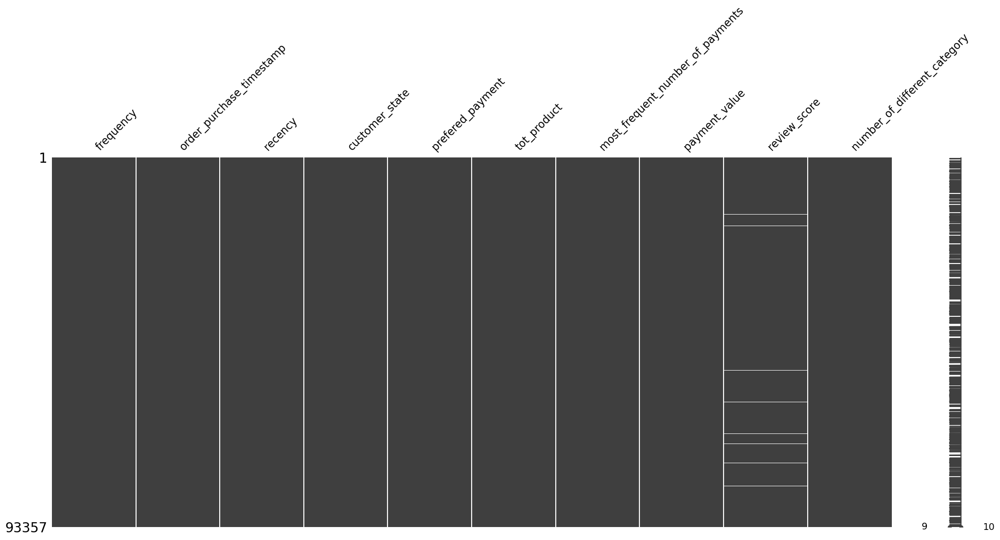

In [114]:
msno.matrix(work_df)

In [116]:
work_df.review_score = work_df.review_score.fillna(0)


In [118]:
work_df.dtypes

frequency                                    int64
order_purchase_timestamp            datetime64[ns]
recency                                      int64
customer_state                              object
prefered_payment                            object
tot_product                                  int64
most_frequent_number_of_payments           float64
payment_value                              float64
review_score                               float64
number_of_different_category                 int64
dtype: object

## Export du dataframe pour segmentation




In [121]:
df.seller_zip_code_prefix = df['seller_zip_code_prefix'].astype('object', copy=False)
df.customer_zip_code_prefix = df['customer_zip_code_prefix'].astype('object', copy = False)


In [123]:
work_df.to_csv('data_agg_cleaned.csv')
df.to_csv('data_cleaned.csv')

In [125]:
work_df

,frequency,order_purchase_timestamp,recency,customer_state,prefered_payment,tot_product,most_frequent_number_of_payments,payment_value,review_score,number_of_different_category
customer_unique_id,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27,111,SP,credit_card,1,8.0,141.90,5.0,1
0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27,114,SP,credit_card,1,1.0,27.19,4.0,1
0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03,536,SC,credit_card,1,8.0,86.22,3.0,1
0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41,320,PA,credit_card,1,4.0,43.62,4.0,1
0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42,287,SP,credit_card,1,6.0,196.89,5.0,1
...,...,...,...,...,...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,1,2017-06-08 21:00:36,446,PE,credit_card,4,10.0,4134.84,5.0,1
fffea47cd6d3cc0a88bd621562a9d061,1,2017-12-10 20:07:56,261,BA,credit_card,1,1.0,84.58,4.0,1
ffff371b4d645b6ecea244b27531430a,1,2017-02-07 15:49:16,567,MT,credit_card,1,1.0,112.46,5.0,1


# Analyse exploratoire : 

In [127]:
work_df.describe().T


,count,mean,min,25%,50%,75%,max,std
frequency,93357.0,1.03342,1.0,1.0,1.0,1.0,15.0,0.209099
order_purchase_timestamp,93357,2018-01-04 03:54:56.246505472,2016-10-03 16:56:50,2017-09-17 18:27:12,2018-01-23 00:18:46,2018-05-07 17:23:11,2018-08-29 15:00:37,NaN
recency,93357.0,236.936673,0.0,113.0,218.0,345.0,694.0,152.584315
tot_product,93357.0,1.869672,1.0,1.0,1.0,1.0,2790.0,14.322201
most_frequent_number_of_payments,93357.0,2.938323,0.0,1.0,2.0,4.0,24.0,2.721441
payment_value,93357.0,180.866333,10.07,64.0,111.55,192.39,15978.65,278.398996
review_score,93357.0,4.126629,0.0,4.0,5.0,5.0,5.0,1.318943
number_of_different_category,93357.0,1.02228,1.0,1.0,1.0,1.0,5.0,0.156129


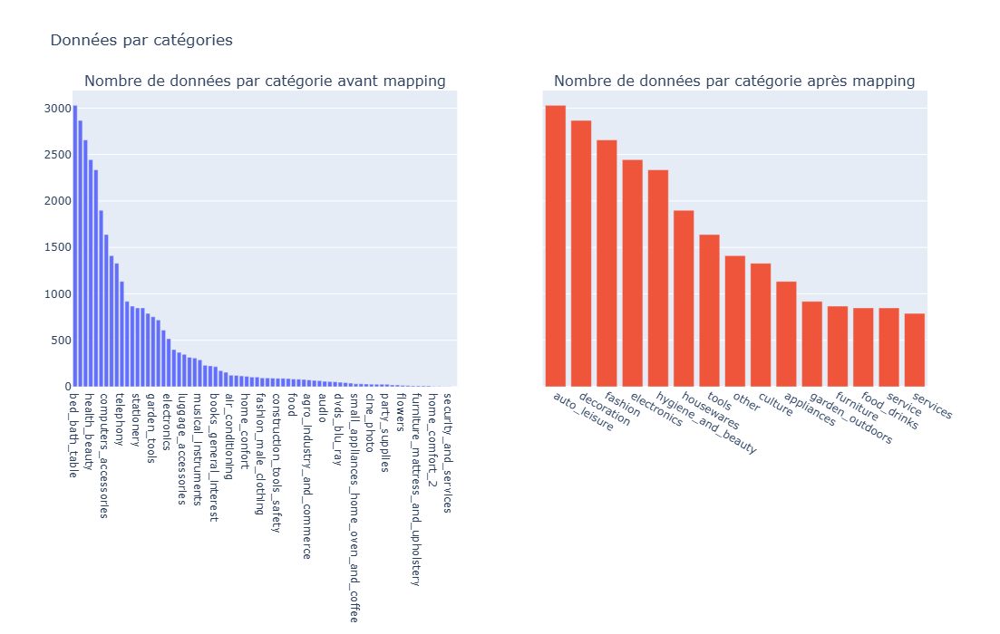

In [129]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=1, cols=2, shared_yaxes=True,
                    subplot_titles=("Nombre de données par catégorie avant mapping",
                                    "Nombre de données par catégorie après mapping"))

fig.add_trace(go.Bar(x = products_en.product_category_name_english.value_counts().index,
                     y= products_en.product_category_name_english.value_counts().values),
                     1, 1)
fig.add_trace( go.Bar(x= products_en.product_category_name.value_counts().index,
                      y= products_en.product_category_name_english.value_counts().values),
                     1,2 )
fig.update_layout( width=1000,
                  height=700,
                  title_text = "Données par catégories",
                  showlegend = False)
              

fig.show()

## Etude de la Récence


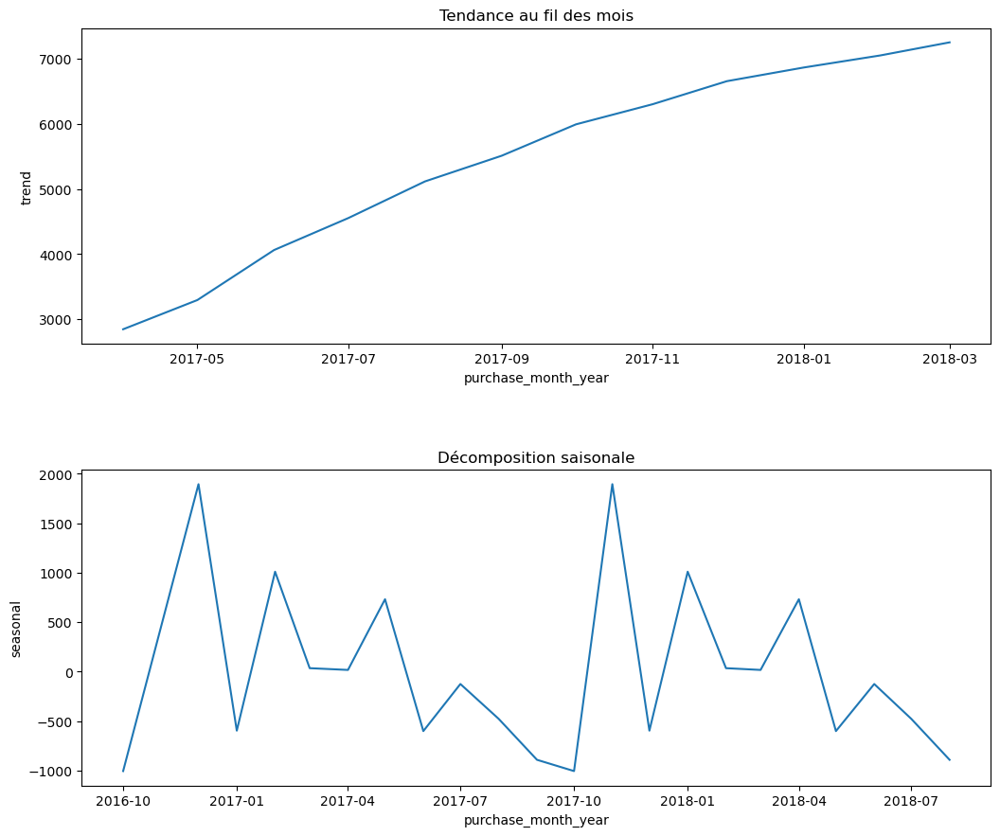

In [137]:
fig, ax = plt.subplots(2,1,figsize=(12,10))

sns.lineplot(x=result.trend.index, y=result.trend, ax=ax[0])
sns.lineplot(x=result.seasonal.index, y=result.seasonal, ax=ax[1])

ax[0].title.set_text('Tendance au fil des mois')
ax[1].title.set_text('Décomposition saisonale')

plt.tight_layout()
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)
plt.show()


La tendance est à l'augmentation constante.

On peut observer deux pics de commandes : décembre 2016 et en novembre 2017.

On voit clairement que la période creuse est fin aout, septembre sur 2017 et 2018.


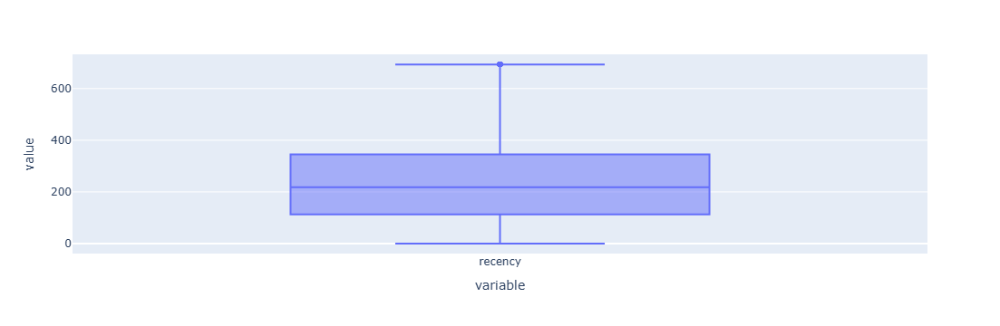

In [141]:
px.box(work_df.recency)


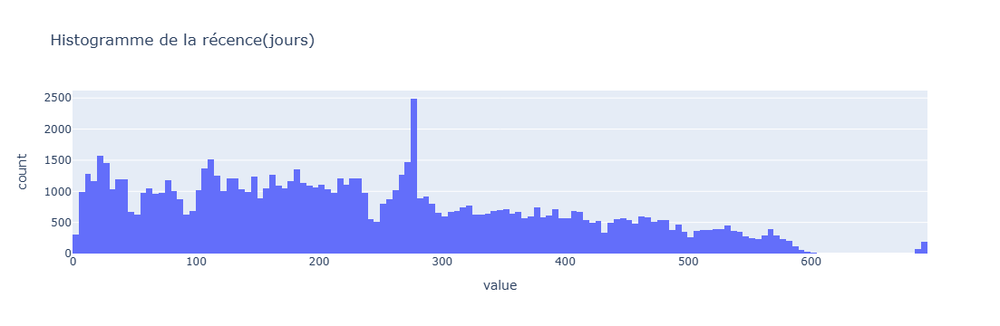

In [143]:
fig = px.histogram(work_df.recency,
             title = "Histogramme de la récence(jours)")
fig.update_layout(showlegend= False)

Nous observons un pic de récence à 9 mois, ce qui qui correspond au mois de décembre de l'année 2017 vu la dernière date d'achat

La valeur médiane est de 7 mois environ.

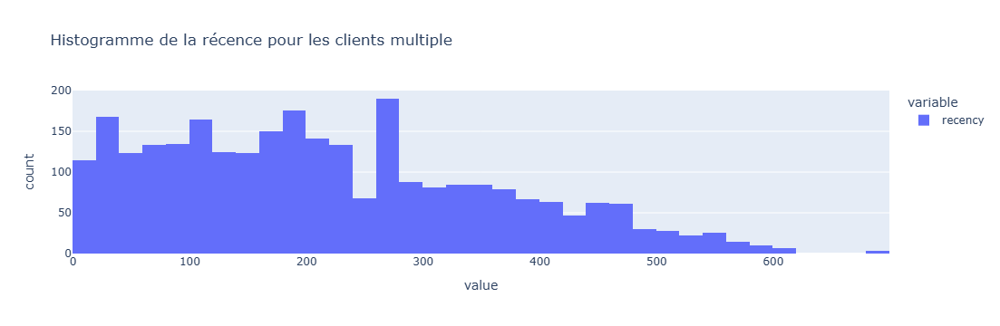

In [145]:
px.histogram(work_df[work_df.frequency > 1 ].recency,
             title = "Histogramme de la récence pour les clients multiple")

In [148]:
#Observons les commandes selon leur mois

work_df["purchase_month"] = work_df.order_purchase_timestamp.apply(lambda x: x.month).map({1:'Jan',2:'Feb',3:'Mar',
                                                                                 4:'Apr',5:'May',6:'Jun',
                                                                                 7:'Jul',8:'Aug',9:'Sep',
                                                                                 10:'Oct',11:'Nov',12:'Dec'})


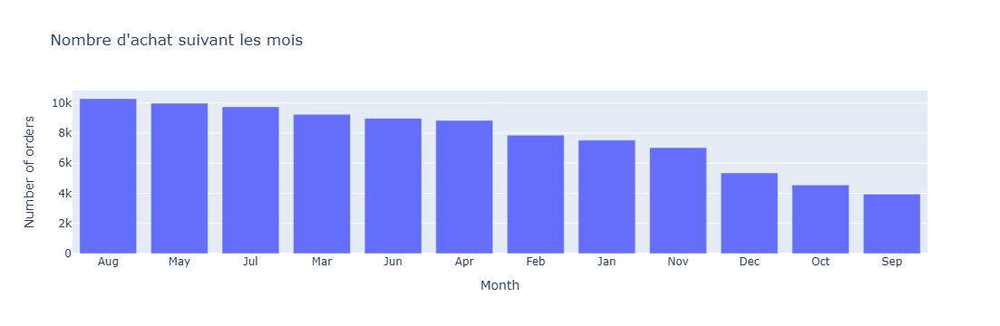

In [150]:
fig = px.bar(work_df.purchase_month.value_counts(),title = "Nombre d'achat suivant les mois")
fig.update_xaxes(title_text= 'Month')
fig.update_yaxes(title_text = 'Number of orders')
fig.update_layout(showlegend = False)
fig.show()

Les commandes sont surtout passées en août et en mai.
Au contraire, la période la moins productive en terme de commandes est en fin d'années.


# Etude de la fréquence d'achat des clients


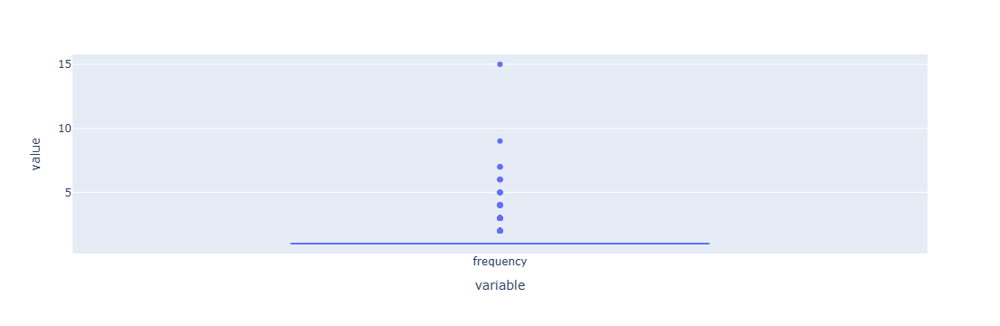

In [156]:
px.box(work_df.frequency)


In [158]:
work_df.frequency.value_counts(normalize=True)

frequency
1     0.969997
2     0.027561
3     0.001939
4     0.000300
5     0.000096
6     0.000054
7     0.000032
9     0.000011
15    0.000011
Name: proportion, dtype: float64

<Axes: xlabel='frequency', ylabel='Density'>

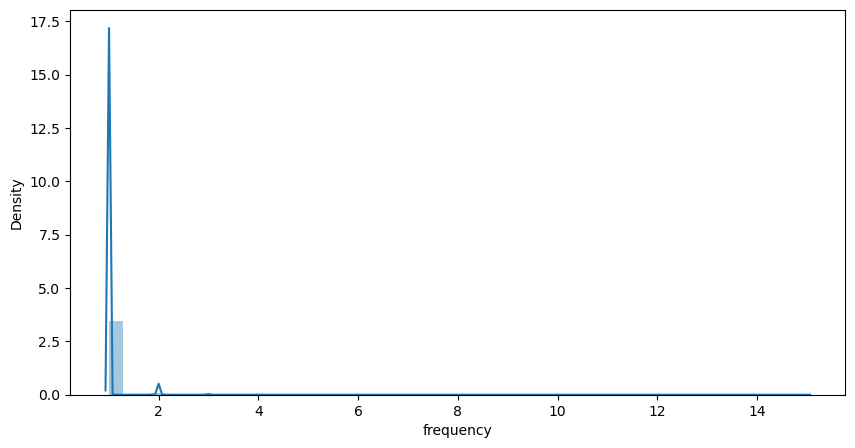

In [160]:
plt.figure(figsize=(10,5))
sns.distplot(work_df.frequency)

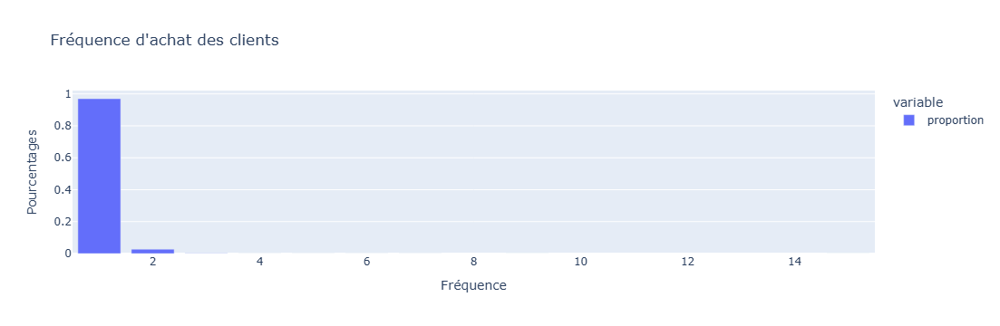

In [162]:
fig =px.bar(work_df.frequency.value_counts(normalize=True), 
           title = "Fréquence d'achat des clients")
fig.update_xaxes(title = "Fréquence")
fig.update_yaxes(title = "Pourcentages")


Il n'y a que 3% des clients qui ont fait plus d'une commande sur le site. Un client a fait 15 commandes sur le site. Valeur atypique mais pas abérrante

### Quel est le montant par commandes?


<Axes: xlabel='payment_value', ylabel='Density'>

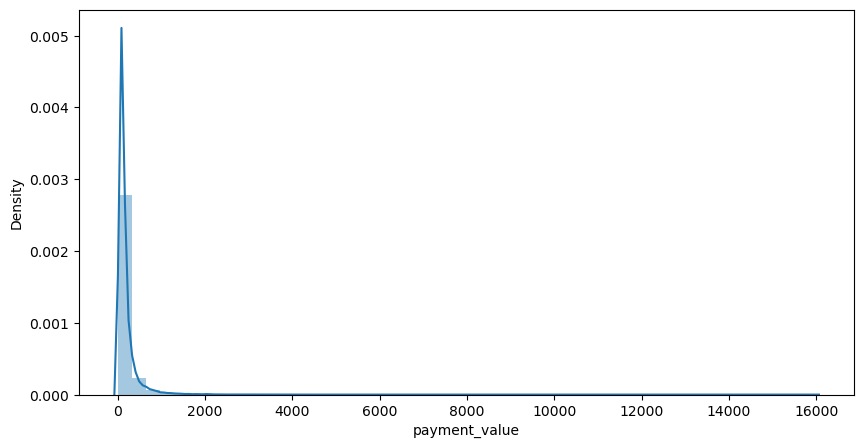

In [166]:
plt.figure(figsize=(10,5))
sns.distplot(work_df.payment_value)

In [168]:
quantile_pay = work_df.payment_value.quantile([0,0.25,0.5,0.75,1])
quantile_pay



0.00       10.07
0.25       64.00
0.50      111.55
0.75      192.39
1.00    15978.65
Name: payment_value, dtype: float64

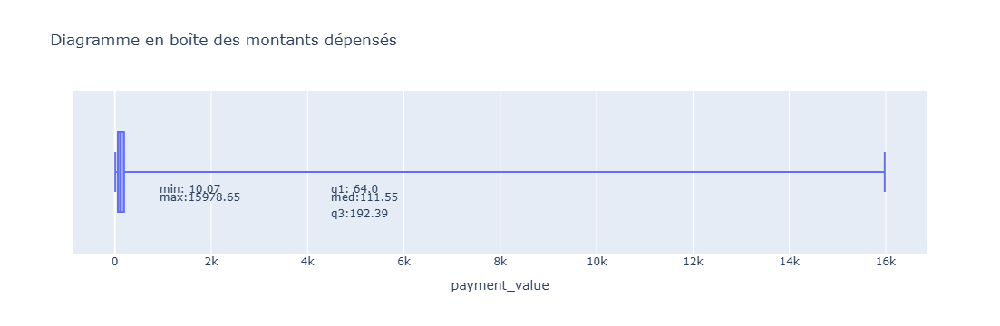

In [170]:
fig = px.box(work_df,x = "payment_value", points = False,
      title = "Diagramme en boîte des montants dépensés")

#for x in zip(["min","q1","med","q3","max"],work_df.payment_value.quantile([0,0.25,0.5,0.75,1]).values):
fig.add_annotation(text="min" + ": " + str(quantile_pay.iloc[0]),
                  xref="paper", yref="paper",
                  x=0.1, y=0.4, showarrow=False)
fig.add_annotation(text="q1" + ": " + str(quantile_pay.iloc[1]),
                  xref="paper", yref="paper",
                  x=0.3, y=0.4, showarrow=False)
fig.add_annotation(text="med" + ":" + str(quantile_pay.iloc[2]),
                  xref="paper", yref="paper",
                  x=0.3, y=0.3, showarrow=False)
fig.add_annotation(text="q3" + ":" + str(quantile_pay.iloc[3]),
                  xref="paper", yref="paper",
                  x=0.3, y=0.2, showarrow=False)
fig.add_annotation(text="max" + ":" + str(quantile_pay.iloc[4]),
                  xref="paper", yref="paper",
                  x=0.1, y=0.3, showarrow=False)


fig.show()

Le montant moyen, de commandes est de 111,55 Reals.
    
La commande minimale fait 10 Reals, c'est peu mais pas un outlier.

La commande la plus élévées fait 16 000 Reals, gros montant mais pas impossible


In [173]:
df.groupby(['customer_unique_id', 'order_id', 'product_category_name'])[['price']].sum().sort_values(ascending=False, by= 'price')


,,,price
customer_unique_id,order_id,product_category_name,
c4b224d2c784bae11ae98b6ae9f2454c,4bfcba9e084f46c8e3cb49b0fa6e6159,culture,21712.20
be74c431147c32ab2d7c7cef5e4a995f,f489949dbe23cf9313deb342913ece0c,electronics,19040.28
1033eef37a760a832f9b2332ce23fdc5,858d458b39082890e96fbb1fed8c2a52,electronics,15598.80
58483a1c055dfb600f57c5b867174542,9de73f3e6157169ad6c32b9f313c7dcb,fashion,15596.00
7a96eb0a685f5c19b7dad29fc802aa64,f398a143c0fe171d965db2096cf064cf,hygiene_and_beauty,12496.00
...,...,...,...
728e4a7d0db4845270091ded0923c71f,38bcb524e1c38c2c1b60600a80fc8999,garden_outdoors,2.90
bd06ce0e06ad77a7f681f1a4960a3cc6,e8bbc1d69fee39eee4c72cb5c969e39d,housewares,2.29
b38211bd797f4fdd81a98b9d1754b606,6e864b3f0ec71031117ad4cf46b7f2a1,tools,0.85


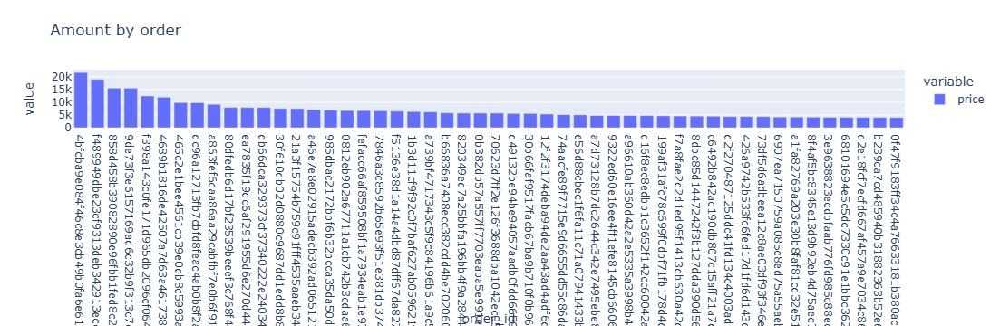

In [175]:
px.bar(df.groupby(['order_id'])[['price']].sum().sort_values(ascending=False, by= 'price').head(50),
      title = "Amount by order")


In [177]:
custom_cat = df.groupby(['customer_unique_id', 'product_category_name'])[['price']].max().sort_values(ascending=False,
                                                                                                      by= 'price')
custom_cat

,,price
customer_unique_id,product_category_name,
dc4802a71eae9be1dd28f5d788ceb526,housewares,6735.00
459bef486812aa25204be022145caa62,electronics,6729.00
ff4159b92c40ebe40454e3e6a7c35ed6,culture,6499.00
da122df9eeddfedc1dc1f5349a1a690c,appliances,4799.00
eebb5dda148d3893cdaf5b5ca3040ccb,appliances,4690.00
...,...,...
bd06ce0e06ad77a7f681f1a4960a3cc6,housewares,2.29
317cfc692e3f86c45c95697c61c853a6,hygiene_and_beauty,2.20
d80730c15c647bc8f2ad77c908ba5ca9,tools,0.85


In [179]:
custom_cat.droplevel("customer_unique_id")


,price
product_category_name,
housewares,6735.00
electronics,6729.00
culture,6499.00
appliances,4799.00
appliances,4690.00
...,...
housewares,2.29
hygiene_and_beauty,2.20
tools,0.85


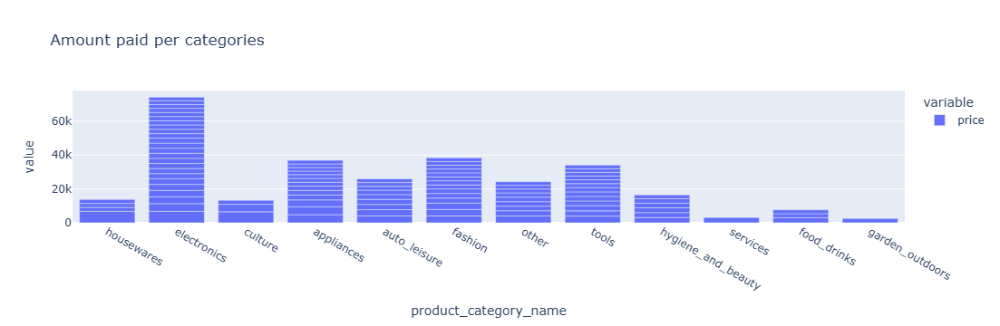

In [181]:
px.bar(custom_cat.droplevel("customer_unique_id").head(100),
      title = "Amount paid per categories")


Les plus gros postes de dépenses sont sur l'électronique comme on pouvait le deviner. Les vêtements et articles de mode. Et les appareils électroménagés.

## Etude de la satisfaction client



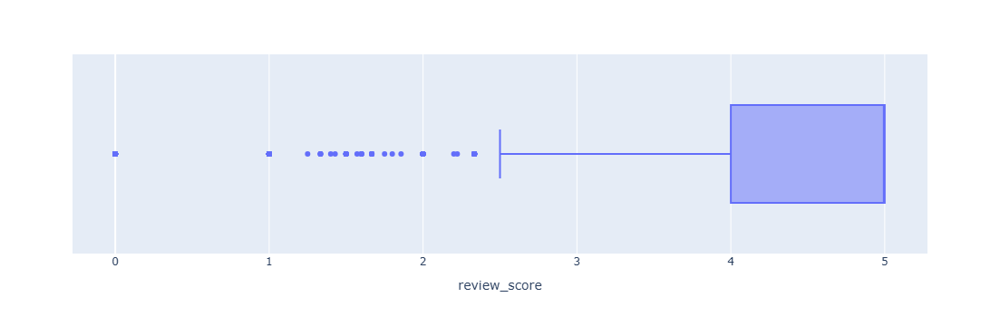

In [185]:
px.box(work_df,x="review_score")

La note moyenne laissée est 5, elle représente 58% des clients.
Il y a 600 notes 0, presque 1% des clients.

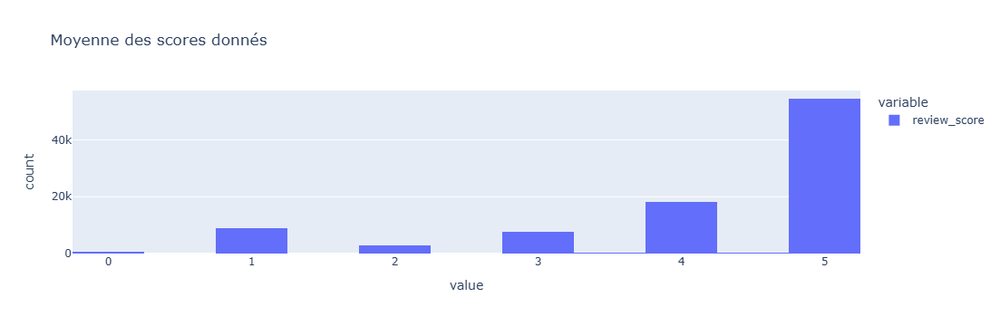

In [188]:
px.histogram(work_df.review_score, nbins=20, title = "Moyenne des scores donnés")


#### Quelle est la catégorie la plus vendue?





In [201]:
category = df.sort_values([
    'customer_id','product_category_name']
    , ascending=False).groupby([
    'customer_id', 'product_category_name']).head(1)[[
        'customer_unique_id', 'product_category_name']]
category.columns = ['customer_unique_id', 'most_purchased_category']
category.set_index('customer_unique_id')
category.most_purchased_category.value_counts()


most_purchased_category
decoration            15671
auto_leisure          15137
electronics           14617
hygiene_and_beauty    11746
fashion               11659
housewares             8431
tools                  5336
other                  4950
culture                2147
furniture              2033
appliances             1914
garden_outdoors        1855
food_drinks            1126
service                 274
services                234
Name: count, dtype: int64

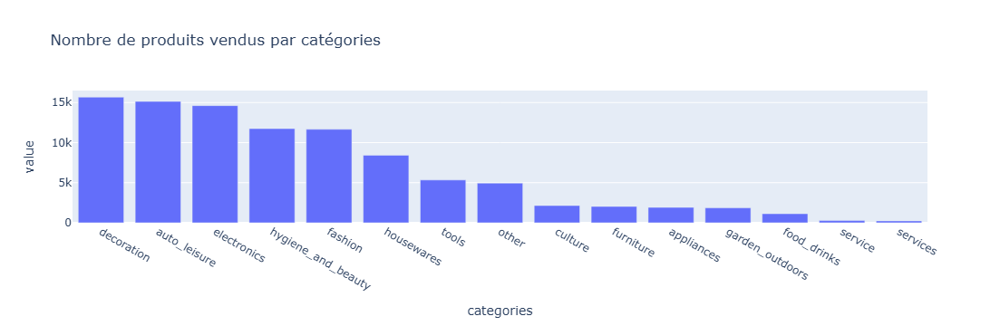

In [203]:
fig = px.bar(category.most_purchased_category.value_counts(), title = 'Nombre de produits vendus par catégories')
fig.update_xaxes(title_text= 'categories')
fig.update_layout(showlegend = False)
fig.show()

Les catégories les plus vendues sont:

les articles de décoration,
de loisirs et pour la voiture et le matériel électronique.


## Analyse des corrélations


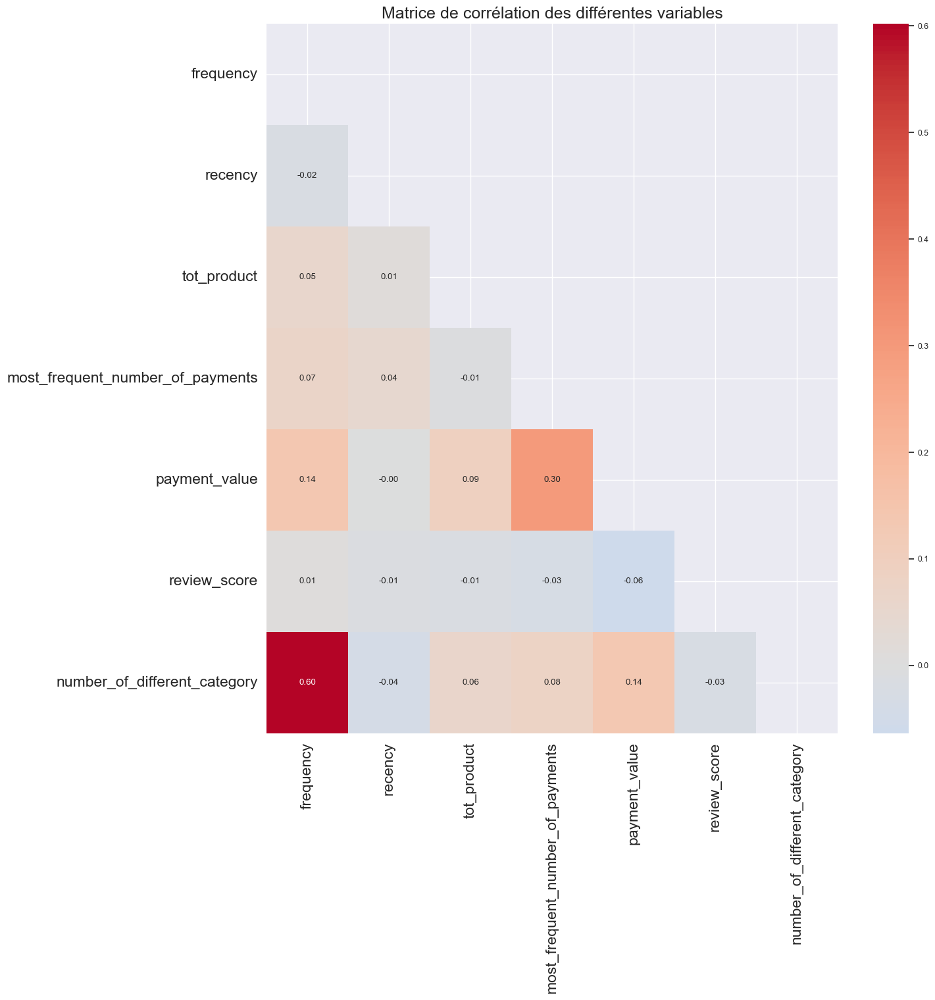

In [206]:
# Sélection des variables numériques du dataset
work_df = work_df.select_dtypes(include='number')

# Calcul et affichage matrice de corrélation
corr_matrix = work_df.corr()

masque = np.zeros_like(corr_matrix)
masque[np.triu_indices_from(masque)] = True

fig = plt.figure(1, figsize=(14,14))
sns.set(font_scale=1.5)
plt.title('Matrice de corrélation des différentes variables')
sns.set(font_scale=0.8)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", mask=masque, fmt=".2f", center=0)
plt.show()

# FIN 